# Supervised Learning Models

---

### Linear & Logistic Regression

> see [regression](regression.ipynb)

### Regularized Linear Models

Regularization is a thechique to prevent models from overfitting by adding a penalty to the model's complexity

It works by modifying the standard loss function by adding a penalty term multiplied by a tuning hyperparameter ($\alpha$) $$\text{Total Loss} = \text{Original Loss} + \alpha \times \text{Penalty Term}$$

In standard Linear Regression the model tries to minimize the MSE (or SSR).

*Scaling* is nessecary.

#### Ridge Regression

Also known as *L2 Regularization*

Penalty term: $\sum_{j = 1}^{p} \beta_{j}^{2}$: the sum of squared coefs.

This results in **coefficient shrinkage** but not driving any coef to zero so all features are kept but their impact is minimized if they aren't useful. This way, it handles multicollinearity, lowers model variance but introduces a small amount of bias. 

Also used in classification.

#### Lasso Regression

Lasso stands for Least Absolute Shrinkage and Selection Operator. Also known as *L1 Regularization*. 

Penalty term: $\sum_{j = 1}^{p} \left| \beta_{j}\right|$

This results in driving some coefs to zero thus implementing an automatic feature selection. Ideal when we have a lot of features but few are important.

#### ElasticNet

Middle ground between ridge and lasso. The penalty term is a simple mix of ridge's and lasso's penalties.

Penalty term: $\rho \sum_{j = 1}^{p} \left| \beta_{j}\right| + \frac{1 - \rho}{2} \sum_{j = 1}^{p} \beta_{j}^{2}$

Useful when:
- collinearity: Lasso would drive to zero all coefs except one while Ridge would split it. 
- more features than samples: Lasso cannot handle this situation

`l1_ratio`: the ratio between ridge and lasso ($\rho$) 

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
RANDOM_SEED = 42

BACKGROUND_COLOR = "lightgray"

In [3]:
# random data generation
np.random.seed(RANDOM_SEED)
X = np.random.rand(1000, 5) # shape: (100, 5)
# only 2 features matter
y = 3 * X[:, 0] + 1.5 * X[:, 1] + np.random.randn(1000) * 0.5

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_scaled, y_train)

elastic_net_model = ElasticNet(alpha=0.1, l1_ratio=0.7)
elastic_net_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)
y_pred_lasso = lasso_model.predict(X_test_scaled)
y_pred_elastic_net = elastic_net_model.predict(X_test_scaled)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
mse_elastic_net = mean_squared_error(y_test, y_pred_elastic_net)
r2_ridge = r2_score(y_test, y_pred_ridge)
r2_lasso = r2_score(y_test, y_pred_lasso)
r2_elastic_net = r2_score(y_test, y_pred_elastic_net)

print("Ridge model: ")
print(f"Coefficients: {ridge_model.coef_}")
print(f"Intercept: {ridge_model.intercept_}")
print(f"MSE: {mse_ridge}")
print(f"R-squared: {r2_ridge}")
print()
print("Lasso model: ")
print(f"Coefficients: {lasso_model.coef_}")
print(f"Intercept: {lasso_model.intercept_}")
print(f"MSE: {mse_lasso}")
print(f"R-squared: {r2_lasso}")
print()
print("ElasticNet model: ")
print(f"Coefficients: {elastic_net_model.coef_}")
print(f"Intercept: {elastic_net_model.intercept_}")
print(f"MSE: {mse_elastic_net}")
print(f"R-squared: {r2_elastic_net}")

Ridge model: 
Coefficients: [ 0.9147671   0.40632701 -0.00798101 -0.01941775 -0.00572248]
Intercept: 2.1906717122056016
MSE: 0.2785633279385628
R-squared: 0.7372721738182584

Lasso model: 
Coefficients: [ 0.81405999  0.30486204 -0.         -0.         -0.        ]
Intercept: 2.190671712205601
MSE: 0.30262392724825593
R-squared: 0.7145793484559055

ElasticNet model: 
Coefficients: [ 0.81993629  0.32524158 -0.         -0.         -0.        ]
Intercept: 2.1906717122056016
MSE: 0.29597649968965895
R-squared: 0.7208488894076708


The rising question is which $\alpha$ and $\rho$ should we use? Sklearn handles this with Cross-Validation. 

Warning: This method requires large dataset.

In [4]:
from sklearn.linear_model import LassoCV #, RidgeCV, ElasticNetCV

In [5]:
lasso_alphas = np.arange(0.01, 0.2, step=0.01)
lasso_cv_model = LassoCV(alphas=lasso_alphas, cv=5)
lasso_cv_model.fit(X_train_scaled, y_train)

y_pred_lasso_cv = lasso_cv_model.predict(X_test_scaled)
r2_lasso_cv = r2_score(y_test, y_pred_lasso_cv)
mse_lasso_cv = mean_squared_error(y_test, y_pred_lasso_cv)

print(f"Best alpha: {lasso_cv_model.alpha_}")
print(f"Coefficients: {lasso_cv_model.coef_}")
print(f"Intercept: {lasso_cv_model.intercept_}")
print(f"MSE: {mse_lasso_cv}")
print(f"R-squared: {r2_lasso_cv}")

Best alpha: 0.01
Coefficients: [ 0.90606411  0.39692705 -0.         -0.0098962  -0.        ]
Intercept: 2.1906717122056016
MSE: 0.2788285832226956
R-squared: 0.7370219975129307


### Polynomial Regression

Sometimes data is more complex than a straight line and we need a more complex model to capture the relationships.


Formula: $y = \beta_{0} + \beta_{1} X + \beta_{2} X^{2} + \beta_{3} X^{3} + \ldots + \beta_{n} X^{n}$

Degree: 
- too small: underfitting
- too large: overfitting

Overfitting is really common in PolynomialRregression. Ridge and Lasso can be utilized here.

In [6]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [7]:
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

# IMPORTANT: transforms X to polynomial
# creates [X, X^2]
# include_bias=False because linear regression has its own intercept 
# and ridge, lasso require no bias
poly_transformer = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly_transformer.fit_transform(X_train)
X_test_poly = poly_transformer.transform(X_test)

# If you want to scale ALWAYS AFTER POLY TRANS 
# because powers blow the scale and negative values loose their meaning

# scaler = StandardScaler()
# X_train_poly_scaled = scaler.fit_transform(X_train_poly)
# X_test_poly_scaled = scaler.transform(X_test_poly)

# we fit a linear reg model with poly X
lin_model = LinearRegression()
lin_model.fit(X_train_poly, y_train)

y_pred = lin_model.predict(X_test_poly)
r2 = r2_score(y_test, y_pred)

print(f"Coefficients: {lin_model.coef_}")
print(f"Intercept: {lin_model.intercept_}")
print(f"R-squared: {r2}")

Coefficients: [[0.97658612 0.4597322 ]]
Intercept: [2.11698253]
R-squared: 0.8511786690618607


In [8]:
import matplotlib.pyplot as plt

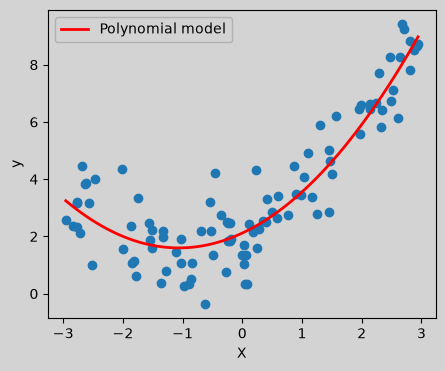

In [9]:
plt.figure(figsize=(5,4), facecolor=BACKGROUND_COLOR)
plt.gca().set_facecolor(BACKGROUND_COLOR)
plt.scatter(X, y)

space = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
poly_space = poly_transformer.transform(space)
y_plot = lin_model.predict(poly_space)

plt.plot(space, y_plot, color="red", linewidth=2, label="Polynomial model")

plt.legend(facecolor=BACKGROUND_COLOR, edgecolor="darkgray")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

### Learning Curves

Plots the model performance (e.g. mse, R-squared, accuracy) both on train and validatoin set against training set size.

In polynomial regression this plots helps us whether the model underfits or overfits the data.

How to spot underfitting:
- training error starts from zero but increases very fast and plateaus very high
- validation error starts high and is stabilized near train error
- both curves meet very soon very high

How to spot overfitting:
- training error stays low
- validation error stays high
- big gap between the two curves

This technique helps us pick a proper degree for Polynomial regression.

In [10]:
def plt_learning_curves(model, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)
    train_errors, val_errors = [], []
    for m in range(1, len(X_train)):
        model.fit(X_train[:m], y_train[:m])
        y_train_pred = model.predict(X_train[:m])
        y_val_pred = model.predict(X_val[:m])
        train_errors.append(mean_squared_error(y_train[:m], y_train_pred))
        val_errors.append(mean_squared_error(y_val[:m], y_val_pred))

    plt.figure(figsize=(5,4), facecolor=BACKGROUND_COLOR)
    plt.gca().set_facecolor(BACKGROUND_COLOR)

    plt.plot(np.sqrt(train_errors), color="red", linewidth=2, label="train")
    plt.plot(np.sqrt(val_errors), color="blue", linewidth=2, label="validation")

    plt.ylim(0, 2.5)
    plt.legend(facecolor=BACKGROUND_COLOR, edgecolor="darkgray")
    plt.xlabel("Train Set Size")
    plt.ylabel("RMSE")
    plt.show()
    

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import learning_curve

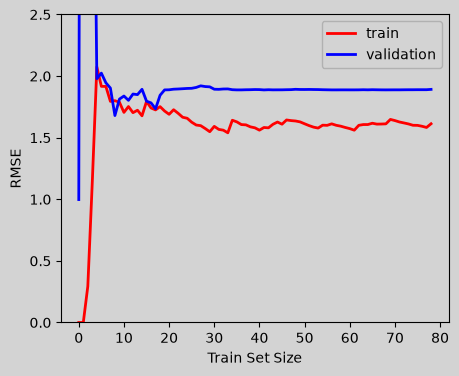

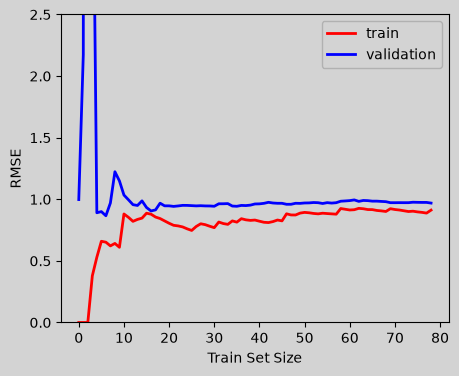

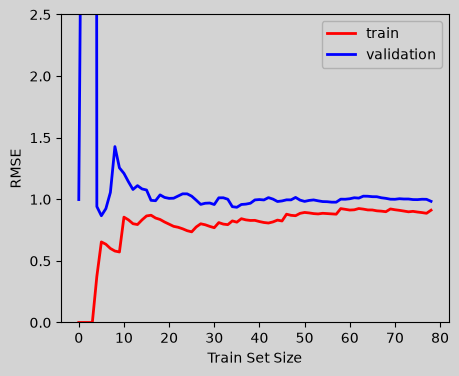

In [12]:
for deg in range(1, 4):
    poly_pipeline = Pipeline([
        ("poly_features", PolynomialFeatures(degree=deg, include_bias=False)),
        ("linear_reg", LinearRegression()),
    ])
    plt_learning_curves(poly_pipeline, X, y)

From the above we observe underfit, good fit and overfit respectively.

### Logistic Regression (continue)

Sklearn's `LogisticRegression` uses regularization so it has these hyperparameters:
- penalty: `Literal['l1', 'l2', 'elasticnet'] | None = "l2"`: regularization method
- C: inverse of alpha meaning the higher the value of C the less the model is regularized

### Softmax Regression

Used for **multiclass classification**. 

How it works:
- score (logits): $s_{k} \left(X\right) = X \cdot \beta_{k}$: a linear equation for every category k.
- Softmax function: $\hat{p}_{k} = \sigma \left(\right. s \left(X\right) \left.\right)_{k} = \frac{e^{s_{k} \left(X\right)}}{\sum_{j = 1}^{K} e^{s_{j} \left(X\right)}}$: probability calculation
- Prediction is the category with the highest probability 

Cost function: **Cross Entropy Loss**

Punishes the model really hard if it gives a very low probability for a positive class. For example if the true label is "Cat" and the model gives probability of:
- 0.95: cost is almost zero
- 0.01: cost is huge

Sklearn: 
- older versions: add `multi_class='multinomial'` parameter to LogisticRegression
- new versions: sklearn automatically detects wether it should use softmax or not


#### Softmax vs Sigmoid:

Sigmoid is used for binary classification while Softmax for multiclass classification. When the problem requires multiclass classifcation where there's only one valid class (e.g. bird, dog, cat) we use softmax because the sum of all probabilities is 1. When there are more valid classes (e.g. happy, energetic, sad feeling in audio) we use sigmoid because every class can have a high probability.

In [13]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

In [14]:
iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# by default we have l2 regularization (ridge) and C=1 to prevent overfitting
softmax_reg = LogisticRegression(random_state=RANDOM_SEED)
softmax_reg.fit(X_train_scaled, y_train)

y_pred = softmax_reg.predict(X_test_scaled)
y_proba = softmax_reg.predict_proba(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print("Softmax probabilities for the first test instance:")
print(f"Class 0: {y_proba[0][0]:.4f}, class 1: {y_proba[0][1]:.4f}, class 2: {y_proba[0][2]:.4f}")

Accuracy: 1.0
Softmax probabilities for the first test instance:
Class 0: 0.0115, class 1: 0.8760, class 2: 0.1126


### Stochastic Gradient Descent - SGD

**Optimization algorithm** suitable for large scale and sparse data as it is super efficient, avoids local minima and finds good but not optimal parameters (fluctuations during training).

It wraps models as it is a training method.

Difference between Batch and Stochastic Gradient Descent: Instead of using the whole dataset to calculate loss and update weights (slow) it uses a random (stochastic) sample.

Warning: It requires carefully setting the learning rate in order to stabilize when reaching the goal and scaling.

### Mini-Batch Gradient Descent

In reality this **optimization algorithm** is used because it stands the middle ground between batch and stochastic gd.

It uses instead of a single instance, a subset of instances.

It stays very fast, more stable and can utilize GPU!

In order to select the correct hyperparameter *batch size* we use powers of 2. Small would be 32, large 256.

Sklearn has only `SGDRegressor` and `SGDClassifier` so in order to implement this we use `partial_fit` method.

We use a silly example below because this method is used for large datasets with many features.

In [15]:
from sklearn.linear_model import SGDClassifier

In [16]:
iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

classes = np.unique(y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# hyperparameters
batch_size = 32
epochs = 10

n_samples = X_train_scaled.shape[0]

# loss='log_loss' -> logistic regression, penalty='l2' -> ridge 
mini_batch_gd = SGDClassifier(loss='log_loss', penalty='l2', alpha=0.01,)

for epoch in range(epochs):
    shuffled_indices = np.random.permutation(n_samples)
    X_shuffled = X_train_scaled[shuffled_indices]
    y_shuffled = y_train[shuffled_indices]

    for i in range(0, n_samples, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]

        # training only on this batch
        mini_batch_gd.partial_fit(X_batch, y_batch, classes)

y_pred = mini_batch_gd.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Accuracy: 0.9667


### Support Vector Machines - SVM

Strong, useful and versatile algorithm used mainly for classification while regression is also possible.

#### Classification

Idea: SVM tries to find the right *hyperplane* to distinguish all classed maximizing its distance  (*margin*) with the closest points (*support vectors*) of each class.

![visualization](https://assets.insightmediagroup.io/media/wp-content/uploads/2023/10/1bXlp7LVAPhIay-Pk0MxdlA.png)

Hyperparameter $C$:
- Large C: *Hard* margin requires zero classification mistakes. This works only if the data is linearly separable. Vulnerable to overfitting.
- Small C: *Soft* margin accepts a few classification mistakes to find a smoother line and generalize better. (regularization, less overfitting)

**Kernel Trick** (nonlinear SVM Classification):

Sometimes the data is not linearly separable. The kernel trick projects this into higher dimensions where it is linearly separable. 

kernel types:
- linear
- poly: using polynomial projections
- rbf: similarity features

Similarity Features:

Instead of training with the initial model features we create new ones based on their distance (*similarity*) with certain features of interest (*landmarks*).

**Gaussian RBF - Radial Basis Function**:

Can deal with very complex data.

RBF treats every instance of the dataset as a landmark. It measures their similarity K as: $$K \left(x , x^{'}\right) = exp \left(- \gamma \left\|x - x^{'}\right\|^{2}\right)$$

If two points are very similar $\left\|x - x^{'}\right\| \approx 0$ K is close to 1. If they're far apart it tends to zero.

Hyperparameter $\gamma$:

It controls the impact radius.
- Small γ: large radius -> smooth, simple border -> underfitting
- Large γ: small radius -> steep border -> overfitting

How to choose the right kernel:

We try first the linear kernel (`LinearSVC` because it is much faster than `SVC(kernel='linear')`) especially when the training set is very large. If it is not that large we try the RBF since it works in most cases. If we have time we experiment with other kernels using cross validation and grid search.

In [17]:
from sklearn.svm import SVC
from sklearn.datasets import make_moons

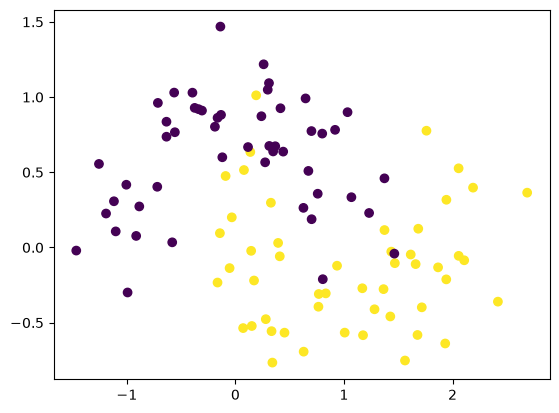

In [18]:
X, y = make_moons(n_samples=100, noise=0.25, random_state=RANDOM_SEED)
plt.scatter(X[:, 0], X[:, 1], c=y)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# small γ, by default c=1
rbf_smooth = SVC(kernel='rbf', gamma=0.1)
rbf_smooth.fit(X_train_scaled, y_train)

# large γ probable overfit
rbf_steep = SVC(kernel='rbf', gamma=10)
rbf_steep.fit(X_train_scaled, y_train)

y_pred_train_smooth = rbf_smooth.predict(X_train_scaled)
y_pred_train_steep = rbf_steep.predict(X_train_scaled)
y_pred_test_smooth = rbf_smooth.predict(X_test_scaled)
y_pred_test_steep = rbf_steep.predict(X_test_scaled)

print("Smooth model")
print(f"Train accuracy: {accuracy_score(y_train, y_pred_train_smooth)}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred_test_smooth)}")

print("Steep model")
print(f"Train accuracy: {accuracy_score(y_train, y_pred_train_steep)}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred_test_steep)}")

Smooth model
Train accuracy: 0.8125
Test accuracy: 1.0
Steep model
Train accuracy: 0.9625
Test accuracy: 0.8


We observe that the smooth model generalizes well and the steep overfits because the dataset is small and noisy. 

Reminder: in order to reduce overfit we can increase the test size or reduce the noise.

In order to find the right c, γ we use `GridSearchCV` to check all the possible combinations from our lists using cross validation.

**Coarse to fine** strategy:

First, we use logarithmic scale for both γ and C (exponential sensitivity) in order to find a good combination (coarse). After that, we use parameters close to the ones we found before to reach optimization (fine).

In [20]:
from sklearn.model_selection import GridSearchCV

In [21]:
# Coarse Search

# we use data from above

# logarithmic scales for C, gamma (best practise)
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'gamma': [0.01, 0.1, 1, 10],
    'kernel': ['rbf'],
}

svm_base = SVC(random_state=RANDOM_SEED)

# cv=5 -> 4 * 4 * 5 = 80 trainings
grid_search = GridSearchCV(
    estimator=svm_base,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1, # use all cpu cores
)

grid_search.fit(X_train_scaled, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best score during cv: {grid_search.best_score_:.4f}")

best_svm_model = grid_search.best_estimator_
y_pred = best_svm_model.predict(X_test_scaled)

print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")

Best params: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
Best score during cv: 0.9250
Test accuracy: 0.9500


In [22]:
# Fine Search

# Since best c and γ are 1 we search in [0.4, 2.0] for both

param_grid_fine = {
    'C': np.linspace(0.4, 2.0, num=9),
    'gamma': np.linspace(0.4, 2.0, num=9),
    'kernel': ['rbf'],
}

svm_base = SVC(random_state=RANDOM_SEED)

grid_search_fine = GridSearchCV(
    estimator=svm_base,
    param_grid=param_grid_fine,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
)

grid_search_fine.fit(X_train_scaled, y_train)

print(f"Best params: {grid_search_fine.best_params_}")
print(f"Best score during cv: {grid_search_fine.best_score_:.4f}")

best_fine_svm_model = grid_search_fine.best_estimator_
y_pred = best_fine_svm_model.predict(X_test_scaled)

print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")

Best params: {'C': np.float64(0.6000000000000001), 'gamma': np.float64(1.4), 'kernel': 'rbf'}
Best score during cv: 0.9375
Test accuracy: 1.0000


We observe that the fine search indeed optimized the parameters. Due to fact that the dataset is very small the split of train and test affects the accuracy a lot. Test accuracy of 1.0 is mostly luck. By increasing the dataset samples or changing the split's random state and tuning the fine search again if needed we can get a more logical test accuracy.

#### Regression

Idea: We try to maximize the number of instances that belong in the line (or in general curve). Note that the curve has a width ($\epsilon$) meaning it is more like a tube.

![visualization](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*mr3tPTzUvwQ8FsetbRkjFA.png)

For every point inside the tube we consider zero error. For every point outside the tube we add error and consider it as a support vector. That's the reason SVR is called $\epsilon$-insensitive (insensitive to error inside the tube).

Hyperparameter $\epsilon$: "tube width"
- Small ε: too strict model -> more sv -> overfitting
- Large ε: simpler -> less sv -> underfitting

Just like in classification we have hyperparameter $C$ and kernel.

Why SVR over Linear/Polynomial regression:
- robust to outliers
- flexibility due to rbf kernel

In [23]:
from sklearn.svm import SVR

In [ ]:
# Coarse search

np.random.seed(RANDOM_SEED)
X = np.sort(np.random.rand(100, 1) * 6)
y = np.sin(X).ravel() + np.random.randn(100) * 0.1

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

# because we feed this grid in a pipeline we use the prefix: 'svr__'
param_grid = {
    'svr__C': [0.1, 1, 10, 100],
    'svr__gamma': [0.01, 0.1, 1, 10],
    'svr__epsilon': [0.01, 0.05, 0.1, 0.2],
}

svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf", C=10.0, epsilon=0.1, gamma=0.5)),
])

grid_search = GridSearchCV(
    estimator=svr_pipeline,
    param_grid=param_grid,
    scoring='r2',
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score during cv: {grid_search.best_score_}")
print(f"Test R-squared: {r2_score(y_test, y_pred):.4f}")
print(f"Test MSE: {mean_squared_error(y_test, y_pred):.4f}")

Best parameters: {'svr__C': 1, 'svr__epsilon': 0.01, 'svr__gamma': 1}
Best score during cv: 0.9792176071051479
Test R-squared: 0.9878
Test MSE: 0.0075


Note: SVMs can be used for outlier detection